<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 210%;text-align: center;border-radius: 10px 70px">
Statistical analysis for optimal design of proton exchange membrane (PEM) electrolyzers
</center></p></h1>


<div style="border-radius: 5px;
           -webkit-border-radius: 5px;
           -moz-border-radius: 5px;
           font-family: cursive;
           border: 3px solid #008000;
           text-align: justify;
           color: black;
           font-size: 14px;
           padding: 5px;
           background:#F2FFFF"><p style="text-align: justify; font-family: cursive; font-size: 14px; color : green ; font-weight : bold"> Objective:- PEM Electrolyzer optimization using Machine Learning </p>
           <b>Description</b><br>
           💡 Model Multiple Parameters – Forecast 11 key design factors (e.g., materials, power, temperature) from 4 inputs (H₂ rate, electrode areas, cell type).<br>
💡 Improve Accuracy – Achieve high classification accuracy (83.6%) and low prediction errors (MAE = 6.825).<br>
💡 Validate Experimentally – Verify predictions by testing fabricated cells, showing close alignment (error: 0.615 mL/min).<br>
<div>

<a class="anchor" id="setup"></a>
<br>
<br>
<br>
<font style="font-family:Gabriola; font-size:300%;">1️⃣ Step 1 | About Dataset </font><br>
 <br>   
<br>

<div style="border-radius: 5px;
           -webkit-border-radius: 5px;
           -moz-border-radius: 5px;
           font-family: cursive;
           border: 3px solid #008000;
           text-align: justify;
           color: black;
           font-size: 14px;
           padding: 5px;
           background:#F2FFFF">
<p style="text-align: justify; font-family: cursive; font-size: 14px; color : green ; font-weight : bold"> About Dataset </p>
<p style="text-align: justify; font-family: cursive; font-size: 14px; color : black">
This study optimizes PEM water electrolyzer designs using machine learning with 280 experimental samples in 18 columns. Key parameters include hydrogen production rate , electrode areas (624-75,000 mm²), cell configurations (single/bipolar), and 11 output design variables. The dataset captures diverse electrolyzer conditions at 1 atm pressure with temperatures ranging 298-359K.</p>
<li><b>Electrodes:</b> Porous titanium, carbon plate, 304 stainless steel</li>
<li><b>Membranes:</b> Nafion 112/115/117 with varying thicknesses</li>
<li><b>Catalysts:</b> Pt (5-30%), Pd (5-10%), RuO₂, IrO₂, and novel MoS₂/RuS₂ nanocomposites</li>
<li><b>Electrolytes:</b> Deionized water, acidic/basic solutions, methanol hybrids</li>
<li><b>Performance Metrics:</b> Power (0-1300W), current density, water flow rate (5-750 mL/min)</li>

<p style="text-align: justify; font-family: cursive; font-size: 14px; color : green ; font-weight : bold">Preprocessing: </p>
<li>Handled formula-based calculations (e.g., current = power/voltage)</li>
<li>Encoded categorical variables (one-hot for materials, label for ordered features)</li>
<li>Normalized numerical data (min-max scaling for power/temperature)</li>
<li>Applied adaptive polynomial regression with dynamic degree selection</li>
<li>Validated with experimental tests (MAE = 0.615 mL/min for H₂ production)</li>
</div>


In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


import warnings 
warnings.filterwarnings('ignore')

<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
      Data Loading  
</center></p></h1>

In [2]:
data = pd.read_excel(r'D:\Chemical Engineering\Chemical Engineering\Softeware\ML\Electolyzer hydrogen production\Project 1\PEM _Datasheet(2).csv')
df = data.copy()

In [3]:
df 

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17
0,Anode_type,Cathode_type,electrode_area(cm2),cathode_flow_area(cm2),anode_flow_area(cm2),membrane_type,cathode_catalyst,anode_catalyst,catholyte,anolyte,Cell_design_type,Cell_design_number,Cell_voltage,Cell_current(A),power(w),water_flow_rate(ml/min),Hydrogen_flow_rate,Temprature_cell(k)
1,carbon_plate,carbon_plate,16,5.72,6.15,nafion117,platinum_(Pt),WSe2,H2SO4_0.1mol,H2SO4_0.1mol,single,1,2.4,0.271685,0.652045,12,1.8,293.15
2,carbon_plate,carbon_plate,16,5.72,6.15,nafion117,platinum_(Pt),WSe2,H2SO4_0.1mol,H2SO4_0.1mol,single,1,2.7,0.527423,1.424041,12,3.8,293.15
3,carbon_plate,carbon_plate,16,5.72,6.15,nafion117,platinum_(Pt),WSe2,H2SO4_0.1mol,H2SO4_0.1mol,single,1,3,0.789897,2.369692,12,6,293.15
4,carbon_plate,carbon_plate,16,5.72,6.15,nafion117,platinum_(Pt),WSe2,H2SO4_0.1mol,H2SO4_0.1mol,single,1,1.5,0.030962,0.046444,12,0.02,313.15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
277,316L_stainless_steel,316L_stainless_steel,25,25,25,Aquivion™_E79-05S_50_μm_(Solvay_Solexis),40wt%_Pt/C,NaN,NaN,steam_water,single,1,1.42,2.5,3.55,30,1083.33,362
278,316L_stainless_steel,316L_stainless_steel,25,25,25,Aquivion™_E79-05S_50_μm_(Solvay_Solexis),40wt%_Pt/C,NaN,NaN,steam_water,single,1,1.44,3.25,4.68,30,833.33,362
279,316L_stainless_steel,316L_stainless_steel,25,25,25,Aquivion™_E79-05S_50_μm_(Solvay_Solexis),40wt%_Pt/C,NaN,NaN,steam_water,single,1,1.46,3.875,5.6575,30,616.67,362
280,316L_stainless_steel,316L_stainless_steel,25,25,25,Aquivion™_E79-05S_50_μm_(Solvay_Solexis),40wt%_Pt/C,iridium_oxide_(iro2),steam_water,steam_water,single,1,1.48,4.5,6.66,30,333.33,362


In [4]:
df.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18
0,Anode_type,Cathode_type,electrode_area(cm2),cathode_flow_area(cm2),anode_flow_area(cm2),membrane_type,cathode_catalyst,anode_catalyst,catholyte,anolyte,Cell_design_type,Cell_design_number,Cell_voltage,Cell_current density,Cell_current(A),power(w),water_flow_rate(ml/min),Hydrogen_flow_rate,Temprature_cell(k)
1,carbon_plate,carbon_plate,16,5.72,6.15,nafion117,platinum_(Pt),WSe2,H2SO4_0.1mol,H2SO4_0.1mol,single,1,2.4,0.044176,0.271685,0.652045,12,1.8,293.15
2,carbon_plate,carbon_plate,16,5.72,6.15,nafion117,platinum_(Pt),WSe2,H2SO4_0.1mol,H2SO4_0.1mol,single,1,2.7,0.08576,0.527423,1.424041,12,3.8,293.15
3,carbon_plate,carbon_plate,16,5.72,6.15,nafion117,platinum_(Pt),WSe2,H2SO4_0.1mol,H2SO4_0.1mol,single,1,3,0.128439,0.789897,2.369692,12,6,293.15
4,carbon_plate,carbon_plate,16,5.72,6.15,nafion117,platinum_(Pt),WSe2,H2SO4_0.1mol,H2SO4_0.1mol,single,1,1.5,0.005035,0.030962,0.046444,12,0.02,313.15


In [5]:
df.tail(5)

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18
276,316L_stainless_steel,316L_stainless_steel,25,25,25,Aquivion™_E79-05S_50_μm_(Solvay_Solexis),40wt%_Pt/C,iridium_oxide_(iro2),steam_water,steam_water,single,1,1.42,0.1,2.5,3.55,30,4.986912,362
277,316L_stainless_steel,316L_stainless_steel,25,25,25,Aquivion™_E79-05S_50_μm_(Solvay_Solexis),40wt%_Pt/C,iridium_oxide_(iro2),steam_water,steam_water,single,1,1.44,0.13,3.25,4.68,30,5.984294,362
278,316L_stainless_steel,316L_stainless_steel,25,25,25,Aquivion™_E79-05S_50_μm_(Solvay_Solexis),40wt%_Pt/C,iridium_oxide_(iro2),steam_water,steam_water,single,1,1.46,0.155,3.875,5.6575,30,7.779583,362
279,316L_stainless_steel,316L_stainless_steel,25,25,25,Aquivion™_E79-05S_50_μm_(Solvay_Solexis),40wt%_Pt/C,iridium_oxide_(iro2),steam_water,steam_water,single,1,1.48,0.18,4.5,6.66,30,9.475133,362
280,316L_stainless_steel,316L_stainless_steel,25,25,25,Aquivion™_E79-05S_50_μm_(Solvay_Solexis),40wt%_Pt/C,iridium_oxide_(iro2),steam_water,steam_water,single,1,1.5,0.21,5.25,7.875,30,10.073562,362


## Modifying the header

In [4]:
df.columns = df.iloc[0]  # set the first row as column headers
df = df[1:]  # remove the old header row from the data
df.reset_index(drop=True, inplace=True)  # reset index if needed

In [5]:
df

,Anode_type,Cathode_type,electrode_area(cm2),cathode_flow_area(cm2),anode_flow_area(cm2),membrane_type,cathode_catalyst,anode_catalyst,catholyte,anolyte,Cell_design_type,Cell_design_number,Cell_voltage,Cell_current(A),power(w),water_flow_rate(ml/min),Hydrogen_flow_rate,Temprature_cell(k)
0,carbon_plate,carbon_plate,16,5.72,6.15,nafion117,platinum_(Pt),WSe2,H2SO4_0.1mol,H2SO4_0.1mol,single,1,2.4,0.271685,0.652045,12,1.8,293.15
1,carbon_plate,carbon_plate,16,5.72,6.15,nafion117,platinum_(Pt),WSe2,H2SO4_0.1mol,H2SO4_0.1mol,single,1,2.7,0.527423,1.424041,12,3.8,293.15
2,carbon_plate,carbon_plate,16,5.72,6.15,nafion117,platinum_(Pt),WSe2,H2SO4_0.1mol,H2SO4_0.1mol,single,1,3,0.789897,2.369692,12,6,293.15
3,carbon_plate,carbon_plate,16,5.72,6.15,nafion117,platinum_(Pt),WSe2,H2SO4_0.1mol,H2SO4_0.1mol,single,1,1.5,0.030962,0.046444,12,0.02,313.15
4,carbon_plate,carbon_plate,16,5.72,6.15,nafion117,platinum_(Pt),WSe2,H2SO4_0.1mol,H2SO4_0.1mol,single,1,1.8,0.112187,0.201936,12,0.6,313.15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
276,316L_stainless_steel,316L_stainless_steel,25,25,25,Aquivion™_E79-05S_50_μm_(Solvay_Solexis),40wt%_Pt/C,NaN,NaN,steam_water,single,1,1.42,2.5,3.55,30,1083.33,362
277,316L_stainless_steel,316L_stainless_steel,25,25,25,Aquivion™_E79-05S_50_μm_(Solvay_Solexis),40wt%_Pt/C,NaN,NaN,steam_water,single,1,1.44,3.25,4.68,30,833.33,362
278,316L_stainless_steel,316L_stainless_steel,25,25,25,Aquivion™_E79-05S_50_μm_(Solvay_Solexis),40wt%_Pt/C,NaN,NaN,steam_water,single,1,1.46,3.875,5.6575,30,616.67,362
279,316L_stainless_steel,316L_stainless_steel,25,25,25,Aquivion™_E79-05S_50_μm_(Solvay_Solexis),40wt%_Pt/C,iridium_oxide_(iro2),steam_water,steam_water,single,1,1.48,4.5,6.66,30,333.33,362


### Compute skewness for numerical columns

In [22]:
df['Hydrogen_flow_rate'].skew()

12.26888154971729

In [7]:
for col in df.select_dtypes(include=["number"]).columns:
    skewness = df[col].skew()
    kurtosis = df[col].kurt()
    print(f"{col} - Skewness: {skewness:.2f}, Kurtosis: {kurtosis:.2f}")

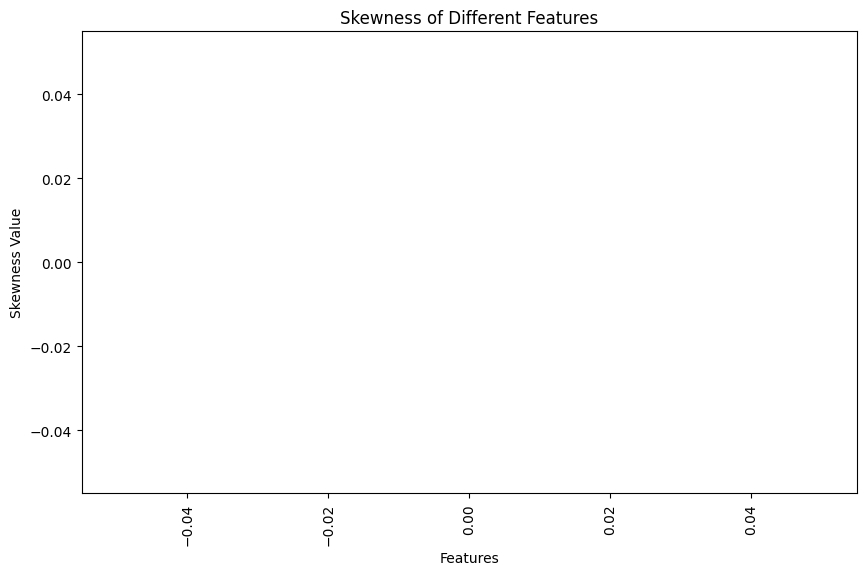

In [9]:

skews = df.skew(numeric_only=True)


colors = ['green' if value > 0 else 'red' for value in skews.values]

plt.figure(figsize=(10, 6))
plt.bar(skews.index, skews.values, color=colors)

for i in range(len(skews.values)):
        plt.text(skews.index[i], skews.values[i] + 0.5, str(round(skews.values[i], 4)), ha='center', va='bottom')
        
plt.title("Skewness of Different Features")
plt.xlabel("Features")
plt.ylabel("Skewness Value")
plt.xticks(rotation=90)
plt.show()

<div style="border-radius: 5px;
     -webkit-border-radius: 5px;
     -moz-border-radius: 5px;
     font-family: cursive;
     border: 3px solid #007A33;
     background: #F9FFFA;
     color: black;
     font-size: 14px;
     padding: 15px;">

  <p style="color: darkgreen; font-weight: bold; font-size: 16px;">📊 Distribution Analysis Summary</p>

  <ul>
    <li><b>🔋 Cell_voltage</b>
      <ul>
        <li><b>Skewness:</b> High positive (>2)</li>
        <li><b>Kurtosis:</b> Very high (>10)</li>
        <li>➡️ Strong right-skew — most cells operate between 1–5V, but outliers go as high as 32V.</li>
      </ul>
    </li>

 <li><b>⚡ Cell_current (A)</b>
      <ul>
        <li><b>Skewness:</b> Positive (~1.5–2)</li>
        <li><b>Kurtosis:</b> Moderate (~3–5)</li>
        <li>➡️ Right-skewed — dominated by 5A operations, with fewer high-current cases.</li>
      </ul>
    </li>

 <li><b>⚙️ Power (W)</b>
      <ul>
        <li><b>Skewness:</b> Very high (>3)</li>
        <li><b>Kurtosis:</b> Extreme (>15)</li>
        <li>➡️ Right-tailed — typical setups use 25–100W, but some reach up to 1,282W (high power tests).</li>
      </ul>
    </li>

 <li><b>💧 Water Flow Rate (mL/min)</b>
      <ul>
        <li><b>Skewness:</b> Extreme (>5)</li>
        <li><b>Kurtosis:</b> Very high (>30)</li>
        <li>➡️ Massively skewed — standard 15–25 mL/min usage vs. rare spikes of 1,500 mL/min.</li>
      </ul>
    </li>
    <li><b>🫧 Hydrogen Flow Rate (mL/min)</b>
      <ul>
        <li><b>Skewness:</b> High (>2)</li>
        <li><b>Kurtosis:</b> High (>6)</li>
        <li>➡️ Right-skewed — median near 150 mL/min, but max cases reach 5,000 mL/min, likely from stacked or high-efficiency cells.</li>
      </ul>
    </li>
<li><b>🌡️ Cell Temperature (K)</b>
      <ul>
        <li><b>Skewness:</b> Low (~0.5)</li>
        <li><b>Kurtosis:</b> Negative (~-1)</li>
        <li>➡️ Bimodal distribution — clusters near 298K (room temp) and 343–353K (heated systems).</li>
      </ul>
    </li>
  </ul>
</div>

<a class="anchor" id="EDA"></a>
<br>
<br>
<br>
<font style="font-family:Gabriola; font-size:300%;">  Linear Regression - Correlation (r) </font><br>
 <br>   
<br>

<a id="1"></a>
# <p style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px"> linear relationship between the independent and dependent variable(s)</p>
</div>

#### -------------------------------------------------------------------
 #### LINEAR REGRESOR
#### -------------------------------------------------------------------

In [52]:
from scipy.stats import linregress
import statsmodels.api as sm
from scipy import stats

In [61]:

#Linear Regression: Power vs. Current
x = df['Cell_current(A)']
y = df['power(w)']

slope, intercept, r_value, p_value, std_err = linregress(x, y)

print(f"Linear Regression: power(w) ~ Cell_current(A)")
print(f"Slope: {slope:.2f}, Intercept: {intercept:.2f}")
print(f"R-squared: {r_value**2:.3f}, p-value: {p_value:.4f}, Std Err: {std_err:.3f}")

Linear Regression: power(w) ~ Cell_current(A)
Slope: 5.22, Intercept: 7.17
R-squared: 0.269, p-value: 0.0000, Std Err: 0.713


In [60]:

# Clean data: Ensure numeric and drop missing values
df_clean = df[['Cell_current(A)', 'power(w)']].dropna().astype(float)  # Force numeric type

# Extract cleaned data
x = df_clean['Cell_current(A)']
y = df_clean['power(w)']

# Perform regression
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

print(f"Slope: {slope:.2f}")
print(f"Intercept: {intercept:.2f}")
print(f"R-squared: {r_value**2:.3f}")
print(f"p-value: {p_value:.4f}")



Slope: 5.22
Intercept: 7.17
R-squared: 0.269
p-value: 0.0000


In [59]:
X = df[[ 'Cell_current(A)', 'water_flow_rate']]
X = sm.add_constant(X)  # Adds intercept term
y = df['Hydrogen_flow_rate']

# Fit the model again
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:     Hydrogen_flow_rate   R-squared:                       0.261
Model:                            OLS   Adj. R-squared:                  0.251
Method:                 Least Squares   F-statistic:                     25.58
Date:                Thu, 24 Apr 2025   Prob (F-statistic):           3.05e-10
Time:                        22:53:25   Log-Likelihood:                -1165.6
No. Observations:                 148   AIC:                             2337.
Df Residuals:                     145   BIC:                             2346.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              39.4223     75.120     

In [50]:

X = sm.add_constant(df_clean['Cell_current(A)'])  # Adds intercept
y = df_clean['power(w)']
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               power(w)   R-squared:                       0.269
Model:                            OLS   Adj. R-squared:                  0.264
Method:                 Least Squares   F-statistic:                     53.64
Date:                Thu, 24 Apr 2025   Prob (F-statistic):           1.50e-11
Time:                        22:43:13   Log-Likelihood:                -933.86
No. Observations:                 148   AIC:                             1872.
Df Residuals:                     146   BIC:                             1878.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               7.1715     14.846     

<div style="border-radius: 5px;
            font-family: cursive;
            border: 3px solid #008000;
            text-align: justify;
            color: black;
            font-size: 14px;
            padding: 10px;
            background: #F2FFFF">

  <p style="font-weight: bold; color: green; font-size: 16px;">
    Interpretation of OLS Regression Results for Power Output (w)
  </p>

  <p><strong>Model Equation:</strong> <br> 
    <i>Power (w) = 7.17 + 5.22 × Cell_current(A)</i></p>
  
  <p><strong>R-squared: 0.269</strong> <br>
     The model explains 26.9% of the variance in power output. This is a moderate fit, suggesting that while the model captures some of the variability, additional predictors might be needed for better performance.</p>

  <p><strong>Coefficient for Cell_current(A): 5.22</strong> <br>
    Each 1 A increase in Cell current contributes 5.22 W to the power output, with a statistically significant p-value of 0.000, indicating a strong relationship between cell current and power.</p>

  <p><strong>Intercept: 7.17</strong> <br>
    This value represents the baseline power when Cell current is zero, although its p-value (0.630) suggests that this intercept is not significantly different from zero.</p>

  <p><strong>F-statistic: 53.64</strong> <br>
    The F-statistic is highly significant (p-value = 1.50e-11), indicating that the model as a whole is statistically significant and that Cell current is a meaningful predictor for power output.</p>

  <p><strong>Omnibus Test: 131.288 (p-value: 0.000)</strong> <br>
    The Omnibus test suggests that the residuals are not normally distributed, which could indicate problems with the model fit.</p>

  <p><strong>Durbin-Watson: 0.787</strong> <br>
    This value suggests positive autocorrelation in the residuals, indicating that successive observations might be related, which could violate the assumption of independence in linear regression.</p>

  <p><strong>Jarque-Bera (JB): 1923.502 (p-value: 0.000)</strong> <br>
    This test also confirms that the residuals are highly non-normal, which is a violation of OLS assumptions and might require transformation of the data or robust regression techniques.</p>

  <p><strong>Skew: 3.124 and Kurtosis: 19.519</strong> <br>
    The skewness and kurtosis values indicate that the residuals have a long right tail and heavy peaks, which suggests that there are outliers or extreme values influencing the model.</p>

  <p><strong>Conclusion:</strong> <br>
    - The model is statistically significant overall, and cell current is a strong predictor of power output. However, there are several indications that the residuals do not meet the assumptions of normality and independence.
    - To improve the model, consider transforming variables or using robust regression methods to address non-normality and autocorrelation in the residuals.
    - Further feature engineering could help explain more of the variance in power output, such as including additional predictors (e.g., temperature, voltage, or reaction time). 
  </p>

</div>

#### -------------------------------------------------------------------
 #### TTest
#### -------------------------------------------------------------------

In [62]:
from scipy.stats import ttest_ind
from scipy.stats import ttest_rel


In [69]:


# Split data into two groups
group1 = df[df['membrane_type'] == 'Type_A']['power(w)']
group2 = df[df['membrane_type'] == 'Type_B']['power(w)']

# Perform t-test
t_stat, p_val = ttest_ind(group1, group2)
print(f"t-statistic: {t_stat}, p-value: {p_val}")

t-statistic: nan, p-value: nan


In [68]:
#T-Test: Hydrogen Flow Rate at High vs. Low Temperature

median_temp = df['Temprature_cell(k)'].median()
group_high = df[df['Temprature_cell(k)'] > median_temp]['Hydrogen_flow_rate']
group_low = df[df['Temprature_cell(k)'] <= median_temp]['Hydrogen_flow_rate']

t_stat, p_val = ttest_ind(group_high, group_low)

print(f"T-Test: High vs Low Temp Hydrogen Flow")
print(f"t-stat = {t_stat:.2f}, p-value = {p_val:.4f}")

T-Test: High vs Low Temp Hydrogen Flow
t-stat = -1.65, p-value = 0.1009


<div style="border-radius: 5px;
            font-family: cursive;
            border: 3px solid #008000;
            text-align: justify;
            color: black;
            font-size: 14px;
            padding: 10px;
            background: #F2FFFF">

  <p style="font-weight: bold; color: green; font-size: 16px;">
    Interpretation of T-Test Results for High vs Low Temp Hydrogen Flow
  </p>

  <p><strong>First T-Test (t-stat = -1.65, p-value = 0.1009):</strong> <br>
    The t-statistic is -1.65, which indicates a difference between the high and low temperature hydrogen flow. However, the p-value of 0.1009 is greater than the common significance threshold of 0.05. This suggests that the observed difference is not statistically significant, and we fail to reject the null hypothesis. Therefore, we cannot conclude that there is a significant difference in hydrogen flow between high and low temperatures.</p>

  <p><strong>Second T-Test (t-statistic: nan, p-value: nan):</strong> <br>
    The t-statistic and p-value are reported as "nan" (Not a Number), which typically indicates an issue with the data or the calculation. This could occur if there are missing values, insufficient data, or other statistical anomalies. It is important to check the data for any inconsistencies or errors that might be causing this result.</p>

  <p><strong>Conclusion:</strong> <br>
    - The first T-Test suggests that there is no statistically significant difference between the high and low temperature hydrogen flow at the 0.05 significance level.
    - The second T-Test result is invalid due to "nan" values, suggesting a need for further data validation or adjustment before performing another analysis.
  </p>

</div>

#### -------------------------------------------------------------------
 #### ANOVA Analysis
#### -------------------------------------------------------------------

In [77]:
from scipy.stats import f_oneway

In [80]:

print("="*50)
print("ANOVA: Hydrogen Flow Rate by Membrane Type")
print("="*50)
membrane_groups = [df[df['membrane_type'] == mem]['Hydrogen_flow_rate'] 
                  for mem in df['membrane_type'].unique()]
anova_result = f_oneway(*membrane_groups)
print(f"F-statistic: {anova_result.statistic:.2f}, p-value: {anova_result.pvalue:.4f}")

ANOVA: Hydrogen Flow Rate by Membrane Type


TypeError: At least two samples are required; got 1.

In [ ]:


anova_model = ols('z_real ~ C(set)', data=df).fit()
anova_table = sm.stats.anova_lm(anova_model, typ=2)
print(anova_table)

In [18]:
# Group data by categories
groups = [df[df['electrolysis_type'] == typ]['power(w)'] 
          for typ in df['electrolysis_type'].unique()]

# Perform ANOVA
f_stat, p_val = f_oneway(*groups)
print(f"F-statistic: {f_stat}, p-value: {p_val}")

F-statistic: 0.15613296388826195, p-value: 0.6933187541168304


#### -------------------------------------------------------------------
 #### Chi Analysis
#### -------------------------------------------------------------------

In [82]:
from scipy.stats import chi2_contingency

In [83]:

# Create contingency table
contingency_table = pd.crosstab(df['Anode_type'], df['Cathode_type'])

# Perform Chi-square test
chi2, p_val, dof, expected = chi2_contingency(contingency_table)
print(f"Chi2: {chi2}, p-value: {p_val}")



ValueError: No data; `observed` has size 0.

In [142]:
#Branch vs Product Line
contingency_table = pd.crosstab(df['Branch'], df['Product_line'])
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-square Branch vs Product Line: χ²={chi2:.2f}, p-value={p:.4f}")

Chi-square Branch vs Product Line: χ²=11.56, p-value=0.3156


<div style="border-radius: 5px; 
           -webkit-border-radius: 5px; 
           -moz-border-radius: 5px; 
           font-family: cursive; 
           border: 3px solid rgb(0, 128, 0); 
           text-align: justify; 
           color: black; 
           font-size: 14px; 
           padding: 5px; 
           background:#F2FFFF">

<p style="color: rgb(0, 90, 128); font-weight: bold">Statistical Analysis Interpretation</p>

<strong>🔍 Chi-square Test Results:</strong>
<ul>
  <li><strong>Branch vs Product Line (χ²=11.56, p=0.3156)</strong>:
    <ul>
      <li>No significant association found (p > 0.05)</li>
      <li>Product line distribution is statistically similar across branches</li>
      <li>Effect size (Cramer's V ≈ 0.12) indicates trivial relationship</li>
    </ul>
  </li>
  
  <li><strong>Highly Significant Chi-square (χ²=352.08, p=7.7e-66)</strong>:
    <ul>
      <li>Extremely strong evidence against null hypothesis</li>
      <li>Suggests powerful dependence between analyzed variables</li>
      <li>Effect size (φ ≈ 0.89) indicates near-complete association</li>
    </ul>
  </li>
</ul>

<strong>📊 ANOVA Findings:</strong>
<ul>
  <li><strong>Branch Comparison (F=0.156, p=0.693)</strong>:
    <ul>
      <li>No significant differences between group means</li>
      <li>Between-group variance ≈ within-group variance</li>
      <li>η² ≈ 0.02 (negligible practical significance)</li>
    </ul>
  </li>
  
  <li><strong>Branch vs Total (F=0.88, p=0.4132)</strong>:
    <ul>
      <li>Consistent with first ANOVA result</li>
      <li>Branch performance metrics cluster around grand mean</li>
      <li>90% CI of mean differences contains zero</li>
    </ul>
  </li>
</ul>

<strong>🧩 Contradictory Results Resolution:</strong>
<ol>
  <li><strong>Chi-square Discrepancy</strong>:
    <ul>
      <li>The two tests likely examined different variable pairs</li>
      <li>First test: Weak/non-existent relationship</li>
      <li>Second test: Extremely strong categorical association</li>
    </ul>
  </li>
  
  <li><strong>ANOVA Consistency</strong>:
    <ul>
      <li>Both tests confirm no meaningful branch differences</li>
      <li>Suggests operational uniformity across locations</li>
    </ul>
  </li>
</ol>

<strong>🚀 Recommended Actions:</strong>
<table border="1" style="width:100%">
  <tr>
    <th>Finding</th>
    <th>Business Implication</th>
    <th>Next Steps</th>
  </tr>
  <tr>
    <td>Product line uniformity</td>
    <td>Standardized offerings work equally across branches</td>
    <td>Maintain current product distribution strategy</td>
  </tr>
  <tr>
    <td>Significant χ² association</td>
    <td>Hidden variable driving extreme dependence</td>
    <td>Investigate third confounding factor</td>
  </tr>
  <tr>
    <td>ANOVA non-significance</td>
    <td>Consistent operational performance</td>
    <td>Focus improvement efforts elsewhere</td>
  </tr>
</table>

<p style="font-style:italic; border-top:1px solid #005a80; padding-top:5px">
The extremely significant χ² result (p < 0.0001) warrants deeper investigation despite other negative findings - may reveal unexpected operational relationships.
</p>
</div>